In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")


In [2]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("pratikjadhav31/skyservercsv")

print("Path to dataset files:", path)


100%|██████████| 445k/445k [00:00<00:00, 20.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pratikjadhav31/skyservercsv/versions/1


In [3]:
import os
print(os.listdir(path))


['skyserver.csv']


In [4]:
import pandas as pd
df = pd.read_csv(os.path.join(path, "skyserver.csv"))
print(df.head())


          objid          ra       dec         u         g         r         i  \
0  1.237650e+18  183.531326  0.089693  19.47406  17.04240  15.94699  15.50342   
1  1.237650e+18  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922   
2  1.237650e+18  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732   
3  1.237650e+18  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233   
4  1.237650e+18  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492   

          z  run  rerun  camcol  field     specobjid   class  redshift  plate  \
0  15.22531  752    301       4    267  3.722360e+18    STAR -0.000009   3306   
1  16.39150  752    301       4    267  3.638140e+17    STAR -0.000055    323   
2  16.80125  752    301       4    268  3.232740e+17  GALAXY  0.123111    287   
3  15.90438  752    301       4    269  3.722370e+18    STAR -0.000111   3306   
4  16.61326  752    301       4    269  3.722370e+18    STAR  0.000590   3306   

     mjd  fiberid  
0  549

In [5]:
df.info()
df.shape
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237650e+18,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,1.645022e+18,0.143726,1460.986400,52943.533300,353.069400
std,1.577039e+05,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,2.013998e+18,0.388774,1788.778371,1511.150651,206.298149
min,1.237650e+18,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,2.995780e+17,-0.004136,266.000000,51578.000000,1.000000
25%,1.237650e+18,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,3.389248e+17,0.000081,301.000000,51900.000000,186.750000
50%,1.237650e+18,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,4.966580e+17,0.042591,441.000000,51997.000000,351.000000
75%,1.237650e+18,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,2.881300e+18,0.092579,2559.000000,54468.000000,510.000000
max,1.237650e+18,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,9.468830e+18,5.353854,8410.000000,57481.000000,1000.000000


In [6]:
df.drop(['objid','specobjid'],axis=1,inplace=True)

In [7]:
print(df.head())


           ra       dec         u         g         r         i         z  \
0  183.531326  0.089693  19.47406  17.04240  15.94699  15.50342  15.22531   
1  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922  16.39150   
2  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732  16.80125   
3  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233  15.90438   
4  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492  16.61326   

   run  rerun  camcol  field   class  redshift  plate    mjd  fiberid  
0  752    301       4    267    STAR -0.000009   3306  54922      491  
1  752    301       4    267    STAR -0.000055    323  51615      541  
2  752    301       4    268  GALAXY  0.123111    287  52023      513  
3  752    301       4    269    STAR -0.000111   3306  54922      510  
4  752    301       4    269    STAR  0.000590   3306  54922      512  


In [8]:
df.shape

(10000, 16)

In [9]:
df.describe()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,redshift,plate,mjd,fiberid
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,0.143726,1460.986400,52943.533300,353.069400
std,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,0.388774,1788.778371,1511.150651,206.298149
min,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,-0.004136,266.000000,51578.000000,1.000000
25%,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,0.000081,301.000000,51900.000000,186.750000
50%,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,0.042591,441.000000,51997.000000,351.000000
75%,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,0.092579,2559.000000,54468.000000,510.000000
max,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,5.353854,8410.000000,57481.000000,1000.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  object 
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(7), object(1)
memory usage: 1.2+ MB


In [11]:
le=LabelEncoder().fit(df['class'])
df['class']=le.transform(df['class'])
df.head(10)

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,2,0.000590,3306,54922,512
5,183.847174,0.173694,19.43133,18.46779,18.16451,18.01475,18.04155,752,301,4,269,2,0.000315,324,51666,594
6,183.864379,0.019201,19.38322,17.88995,17.10537,16.66393,16.36955,752,301,4,269,0,0.100242,287,52023,559
7,183.900081,0.187473,18.97993,17.84496,17.38022,17.20673,17.07071,752,301,4,269,2,0.000315,3306,54922,515
8,183.924588,0.097246,17.90616,16.97172,16.67541,16.53776,16.47596,752,301,4,270,2,0.000089,323,51615,595
9,183.973498,0.081626,18.67249,17.71375,17.49362,17.28284,17.22644,752,301,4,270,0,0.040508,288,52000,400


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  int64  
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 1.2 MB


In [13]:
x=df.drop('class',axis=1)
y=df['class']

data scaling

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler(copy=True,with_mean=True,with_std=True)
x =scaler.fit_transform(x)
x[:20]

array([[ 0.16745842, -0.58492272,  1.03148637, -0.34855938, -0.83728027,
        -0.94605772, -0.99534154, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36973112,  1.03148936,  1.30931064,  0.66863177],
       [ 0.16886159, -0.58311429,  0.05243046, -0.16653251, -0.15415531,
        -0.08264457, -0.02604308, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36984929, -0.63621258, -0.87919741,  0.91101156],
       [ 0.17057433, -0.58347525,  0.92156796,  0.86709322,  0.59315368,
         0.44120145,  0.31452753, -0.83806089,  0.        ,  0.21085172,
        -0.21147922, -0.05302706, -0.65633905, -0.60919097,  0.77527888],
       [ 0.17455754, -0.58650069, -1.03063038, -0.81362749, -0.63669227,
        -0.52660429, -0.43092107, -0.83806089,  0.        ,  0.21085172,
        -0.20532801, -0.36999261,  1.03148936,  1.30931064,  0.76073609],
       [ 0.17482457, -0.58441247, -1.29023238, -1.17251944, -0.37676237,
        -0.02510121,  0.15827647, -0.83806089, 

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=120)

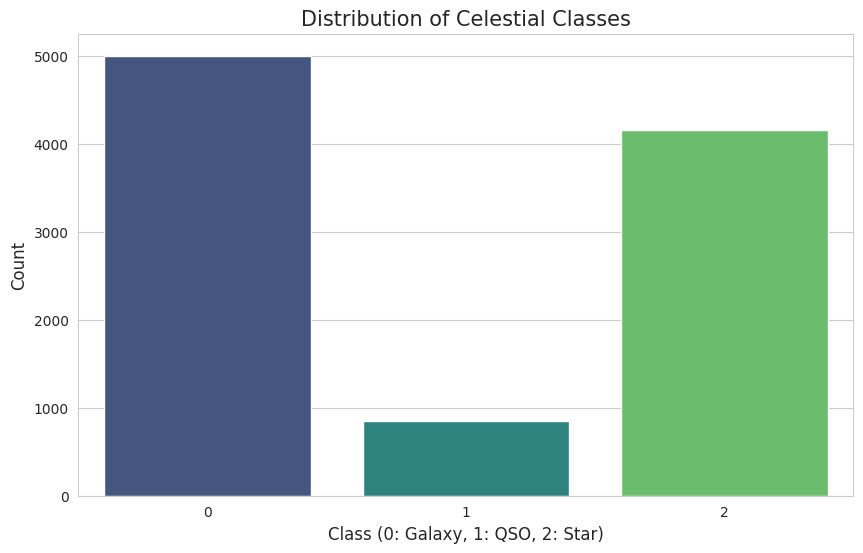

In [34]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(x=df['class'], palette='viridis')

plt.title('Distribution of Celestial Classes', fontsize=15)
plt.xlabel('Class (0: Galaxy, 1: QSO, 2: Star)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

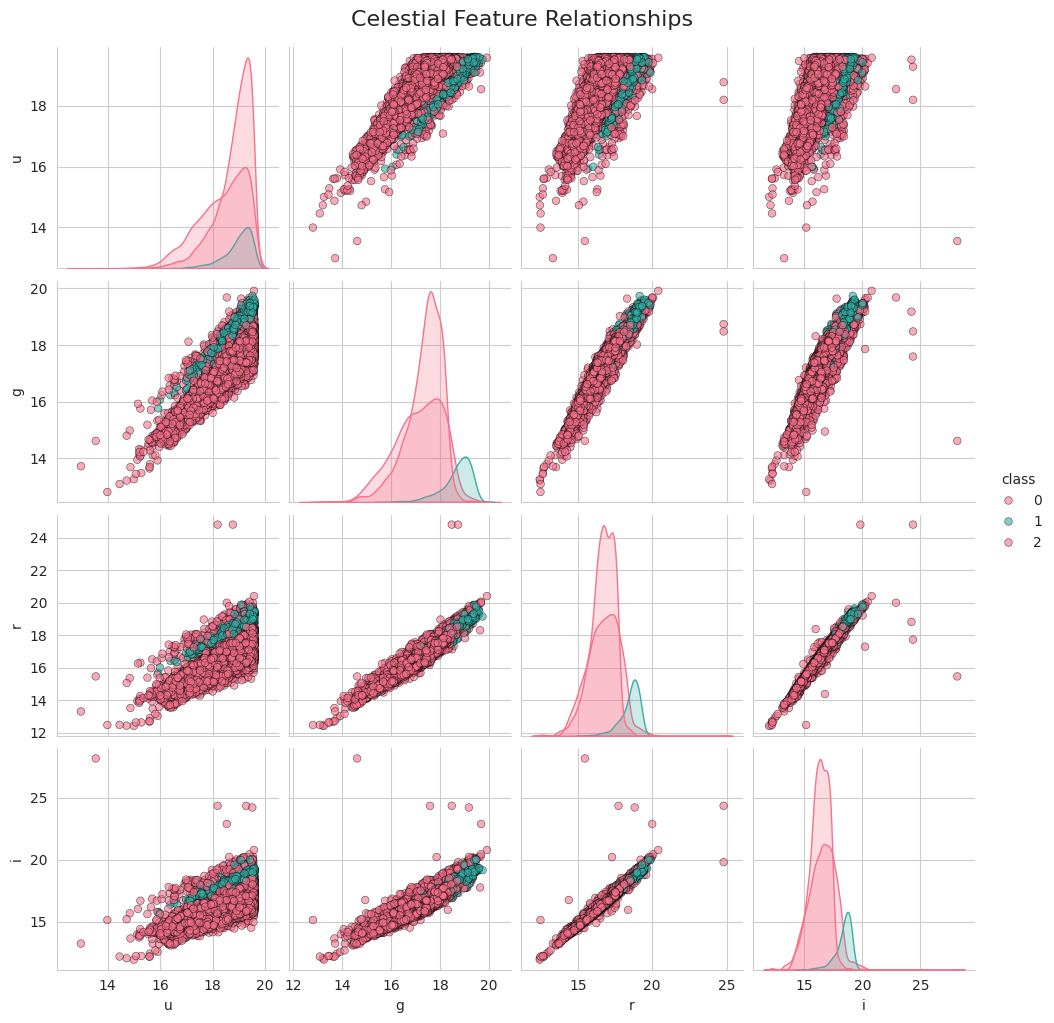

In [35]:
sns.pairplot(df[['u', 'g', 'r', 'i', 'class']],
             hue='class',
             palette='husl',
             plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})

plt.suptitle('Celestial Feature Relationships', y=1.02, fontsize=16)
plt.show()

In [18]:
dtClassifer=DecisionTreeClassifier(max_leaf_nodes=15,max_depth=3)

In [19]:
LRClassifier=LogisticRegression()

In [20]:
NeNeclassifier=KNeighborsClassifier(n_neighbors=3)

In [21]:
dtClassifer.fit(x_train,y_train)
LRClassifier.fit(x_train,y_train)
NeNeclassifier.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [22]:
y_pred=dtClassifer.predict(x_test)
y_predsLR=LRClassifier.predict(x_test)
y_predsNeNe=NeNeclassifier.predict(x_test)

In [23]:
dtClassifer=DecisionTreeClassifier(max_leaf_nodes=15,max_depth=3)

In [24]:
print(y_pred[:10],'/n',y_test[:10])
print("==================================")
print(y_predsLR[:10],"/n",y_test[:10])
print("==================================")
print(y_predsNeNe[:10],"/n",y_test[:10])

[0 0 2 2 0 0 0 0 2 1] /n 3223    0
3686    0
9378    2
7588    2
6390    0
2040    0
4438    0
9198    0
342     2
4210    1
Name: class, dtype: int64
[0 0 2 2 0 0 0 0 2 1] /n 3223    0
3686    0
9378    2
7588    2
6390    0
2040    0
4438    0
9198    0
342     2
4210    1
Name: class, dtype: int64
[0 0 2 2 0 0 0 0 2 1] /n 3223    0
3686    0
9378    2
7588    2
6390    0
2040    0
4438    0
9198    0
342     2
4210    1
Name: class, dtype: int64


classification report

In [25]:
from sklearn.metrics import classification_report

target_names = ["0", "1", "2"]

print("\033[1m Decision Tree -\n \033[0m", classification_report(y_test, y_pred, target_names=target_names))

print("\033[1m Linear Regression -\n \033[0m", classification_report(y_test, y_predsLR, target_names=target_names))

print("\033[1m KNN classifier -\n \033[0m", classification_report(y_test, y_predsNeNe, target_names=target_names))

 Decision Tree -
                precision    recall  f1-score   support

           0       0.99      0.99      0.99      1455
           1       0.98      0.93      0.96       256
           2       0.99      1.00      1.00      1289

    accuracy                           0.99      3000
   macro avg       0.99      0.97      0.98      3000
weighted avg       0.99      0.99      0.99      3000

 Linear Regression -
                precision    recall  f1-score   support

           0       0.98      0.97      0.98      1455
           1       0.98      0.94      0.96       256
           2       0.97      0.99      0.98      1289

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000

 KNN classifier -
                precision    recall  f1-score   support

           0       0.87      0.94      0.91      1455
           1       0.98      0.86      0.91       256
           2 

build a input system to predict the stars quaers etc
do corealtion

In [26]:
# Save models
import joblib

joblib.dump(dtClassifer, "dt_model.pkl")
joblib.dump(LRClassifier, "lr_model.pkl")
joblib.dump(NeNeclassifier, "knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save class names
import json
class_names = list(le.classes_)  # ['GALAXY', 'QSO', 'STAR']
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names:", class_names)

Class names: ['GALAXY', 'QSO', 'STAR']


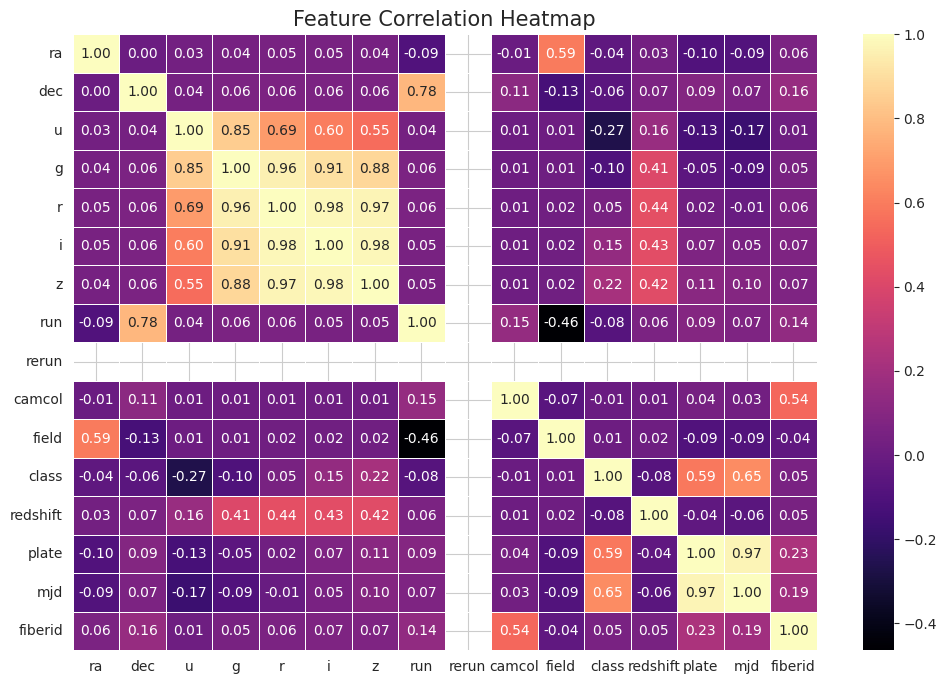

In [36]:
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='magma', fmt='.2f', linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=15)
plt.show()

In [ ]:
from google.colab import files
files.download("dt_model.pkl")
files.download("lr_model.pkl")
files.download("knn_model.pkl")
files.download("scaler.pkl")
files.download("class_names.json")